# Options data cleaning

This notebook applies the cleaning pipeline to the AAPL and SPX options datasets, following the methodology discussed for the thesis (see `data_quality_check.ipynb` for the preceding diagnostic pass, which only inspects the data without modifying it).

**Structure:**
- Part 1 — AAPL options cleaning
- Part 2 — SPX options cleaning (added once Part 1 is validated)

**Part 1 sections (this pass):**
1. Setup and imports
2. Load raw data
3. Basic type fixes (dates, strike price scale)
4. `cfadj` (stock split adjustment) — decision, based on diagnostics in `data_quality_check.ipynb`: no adjustment needed

Further steps (ss_flag filter, bid/ask checks, liquidity filter, minimum maturity filter, moneyness/ITM handling, no-arbitrage checks) will be added next.

## Part 1 — AAPL options cleaning

### 1. Setup and imports

In [82]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats

In [41]:
# Confirm working directory so relative paths resolve correctly
# (this notebook is expected to sit at the project root, same folder as data_quality_check.ipynb)
print("Current working directory:", Path.cwd())

RAW_DATA_DIR = Path("data/raw")
AAPL_OPTIONS_PATH = RAW_DATA_DIR / "AAPL_options_prices.csv"

print("Looking for AAPL options file at:", AAPL_OPTIONS_PATH.resolve())
print("File exists:", AAPL_OPTIONS_PATH.exists())

Current working directory: c:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence
Looking for AAPL options file at: C:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence\data\raw\AAPL_options_prices.csv
File exists: True


### 2. Load raw data

In [42]:
aapl_raw = pd.read_csv(AAPL_OPTIONS_PATH)

print("Shape:", aapl_raw.shape)
aapl_raw.head()

Shape: (1994694, 15)


,secid,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,optionid,cfadj,ss_flag,index_flag,issuer,exercise_style
0,101594,2020-08-31,2020-09-04,C,100000,29.40,29.70,150,411,135212375,4,0,0,APPLE INC,A
1,101594,2020-08-31,2020-09-04,C,100630,28.85,29.10,691,81,135212376,4,0,0,APPLE INC,A
2,101594,2020-08-31,2020-09-04,C,101250,28.15,28.45,137,240,135212377,4,0,0,APPLE INC,A
3,101594,2020-08-31,2020-09-04,C,101880,27.50,27.85,75,130,135212378,4,0,0,APPLE INC,A
4,101594,2020-08-31,2020-09-04,C,102500,26.90,27.20,323,734,135212379,4,0,0,APPLE INC,A


In [43]:
aapl_raw.dtypes

secid               int64
date                  str
exdate                str
cp_flag               str
strike_price        int64
best_bid          float64
best_offer        float64
volume              int64
open_interest       int64
optionid            int64
cfadj               int64
ss_flag             int64
index_flag          int64
issuer                str
exercise_style        str
dtype: object

### 3. Basic type fixes

Convert `date` and `exdate` to proper datetime objects, and rescale `strike_price` (OptionMetrics stores it multiplied by 1000).

In [44]:
# Work on a copy so the raw dataframe stays untouched for reference
aapl = aapl_raw.copy()

aapl["date"] = pd.to_datetime(aapl["date"])
aapl["exdate"] = pd.to_datetime(aapl["exdate"])

print(aapl[["date", "exdate"]].dtypes)
print("Trading date range:", aapl["date"].min(), "to", aapl["date"].max())
print("Expiration date range:", aapl["exdate"].min(), "to", aapl["exdate"].max())

date      datetime64[us]
exdate    datetime64[us]
dtype: object
Trading date range: 2020-08-31 00:00:00 to 2025-08-29 00:00:00
Expiration date range: 2020-09-04 00:00:00 to 2026-08-21 00:00:00


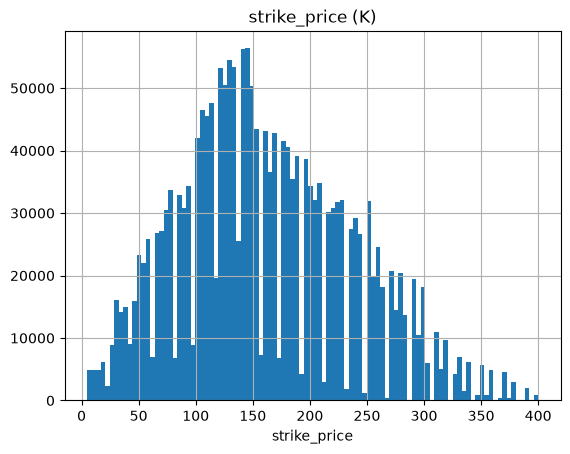

count    1.994694e+06
mean     1.608919e+02
std      7.507302e+01
min      5.000000e+00
25%      1.075000e+02
50%      1.500000e+02
75%      2.125000e+02
max      4.000000e+02
Name: strike_price, dtype: float64


In [45]:
# OptionMetrics stores strike_price multiplied by 1000
aapl["strike_price"] = aapl["strike_price"] / 1000

aapl["strike_price"].hist(bins=100)
plt.title("strike_price (K)")
plt.xlabel("strike_price")
plt.show()

print(aapl["strike_price"].describe())

### 4. Restrict to call options

Following Hutchinson, Lo and Poggio (1994), this analysis is restricted to call options at this stage. Put options are excluded from the dataset rather than reconciled against calls via put-call parity. This keeps option type unambiguous for both the Black-Scholes benchmark and the machine learning models without requiring `cp_flag` as an additional model feature.

In [46]:
# Restrict the dataset to call options only
n_before = len(aapl)
aapl = aapl[aapl["cp_flag"] == "C"].copy()
n_after = len(aapl)

print(f"Rows before: {n_before}")
print(f"Rows after restricting to calls: {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before: 1994694
Rows after restricting to calls: 997347
Rows removed: 997347


### 5. Bid/ask validity checks

This section addresses two distinct issues in `best_bid` and `best_offer`: (i) crossed markets, where `best_bid > best_offer`, which cannot represent a genuine tradable quote and are removed unconditionally; (ii) non-positive bids, which are not technically invalid but indicate illiquid, unreliable quotes. 

In [47]:
# Remove crossed markets: best_bid must not exceed best_offer
n_before = len(aapl)
aapl = aapl[aapl["best_bid"] <= aapl["best_offer"]].copy()
n_after = len(aapl)

print(f"Rows before: {n_before}")
print(f"Rows after removing crossed markets (best_bid > best_offer): {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before: 997347
Rows after removing crossed markets (best_bid > best_offer): 997316
Rows removed: 31


In [48]:
# Remove rows with non-positive best_bid (zero or negative quotes are not valid tradable prices)
n_before = len(aapl)
aapl = aapl[aapl["best_bid"] > 0].copy()
n_after = len(aapl)

print(f"Rows before: {n_before}")
print(f"Rows after removing non-positive best_bid: {n_after}")
print(f"Rows removed: {n_before - n_after}")


Rows before: 997316
Rows after removing non-positive best_bid: 913369
Rows removed: 83947


### 6. Liquidity filter (volume and open interest)

This section examines `volume` and `open_interest` as liquidity indicators. Options with no trading activity and no open positions are unlikely to carry a reliable price signal. Rows are removed only where both `volume` and `open_interest` are zero on the same day, indicating no trading activity and no outstanding positions on that contract. Using `volume == 0` alone would be too aggressive, since many actively traded contracts simply see no trades on a given day without being illiquid. Similarly, using `open_interest == 0` alone would risk removing contracts with genuine same-day trading activity, since open interest is typically reported as of the prior day's close and can lag newly active positions.

In [49]:
n_before = len(aapl)
aapl = aapl[~((aapl["volume"] == 0) & (aapl["open_interest"] == 0))].copy()
n_after = len(aapl)

print(f"Rows before: {n_before}")
print(f"Rows after liquidity filter: {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before: 913369
Rows after liquidity filter: 847997
Rows removed: 65372


## Part 1.2 — AAPL feature engineering

### 7. Remove useless features

In [50]:
columns_to_drop = ["ss_flag", "cfadj", "index_flag", "issuer", "exercise_style", "cp_flag"]
aapl = aapl.drop(columns=columns_to_drop)

print("Remaining columns:", list(aapl.columns))

Remaining columns: ['secid', 'date', 'exdate', 'strike_price', 'best_bid', 'best_offer', 'volume', 'open_interest', 'optionid']


### 8. Merge stock price (S)

Following Hutchinson, Lo and Poggio (1994), moneyness is constructed as `S/K` rather than using the stock price and strike price as separate inputs. This reflects the degree-one homogeneity property of the option pricing function in `(S, K)`, under the assumption that the return distribution of the underlying is independent of the price level (Merton, 1990, Theorem 8.9). Constructing this feature requires the underlying stock price for each option observation, obtained by merging with `AAPL_security_prices.csv` on `date`.

In [ ]:
security_prices = pd.read_csv(RAW_DATA_DIR / "AAPL_security_prices.csv")
security_prices["date"] = pd.to_datetime(security_prices["date"])

Stylized fact check: fat tails in the underlying's return distribution.

Supports the discussion of lognormality in Section 2.3.

In [ ]:
returns = np.log(security_prices["close"] / security_prices["close"].shift(1)).dropna()

excess_kurtosis = stats.kurtosis(returns)          # 0 under normality

std = returns.std()
observed_4sigma = (returns.abs() > 4 * std).sum() # How many days experienced a movement greater than four standard deviations
expected_4sigma = len(returns) * 2 * (1 - stats.norm.cdf(4)) # how many such large movements should you expect if returns were truly normally distributed
# stats.norm.cdf(4) = P(Z < 4): probability under the normal that a value stays below 4 std devs (very close to 1).
# 1 - cdf(4) = P(Z > 4): probability of exceeding +4 std devs (tiny).
# * 2 accounts for both tails, since we took abs(returns) above.
# * len(returns) scales that per-day probability into an expected COUNT over the sample: how many such moves normality predicts we'd see.

print(f"Daily log returns: n = {len(returns)}")
print(f"Excess kurtosis: {excess_kurtosis:.2f}")
print(f"Moves beyond 4 standard deviations: observed = {observed_4sigma}, "
      f"expected under normality = {expected_4sigma:.2f}")

Daily log returns: n = 1255
Excess kurtosis: 4.87
Moves beyond 4 standard deviations: observed = 5, expected under normality = 0.08


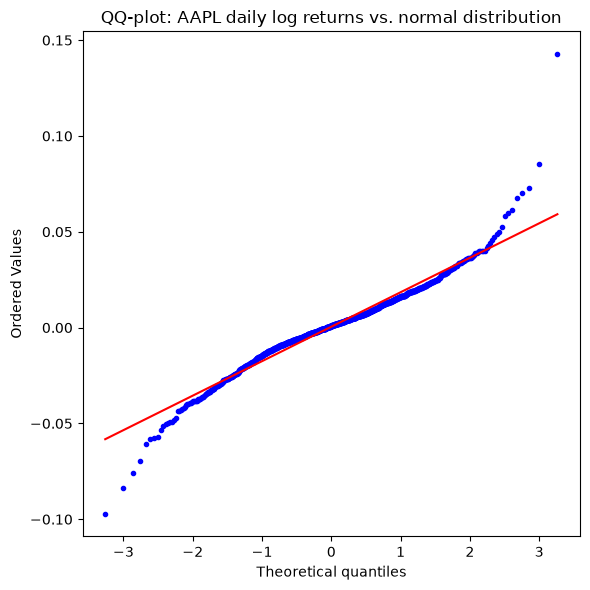

In [85]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(returns, dist="norm", plot=ax)
ax.set_title("QQ-plot: AAPL daily log returns vs. normal distribution")
ax.get_lines()[0].set_markersize(3)
plt.tight_layout()
plt.savefig("qqplot_aapl_returns.pdf")
plt.show()

In [51]:
security_prices = pd.read_csv(RAW_DATA_DIR / "AAPL_security_prices.csv")
security_prices["date"] = pd.to_datetime(security_prices["date"])

n_before = len(aapl)
aapl = aapl.merge(security_prices[["date", "close"]], on="date", how="left")
n_after = len(aapl)

print(f"Rows before merge: {n_before}")
print(f"Rows after merge: {n_after}")
print(f"Rows with missing underlying price after merge: {aapl['close'].isna().sum()}")

Rows before merge: 847997
Rows after merge: 847997
Rows with missing underlying price after merge: 0


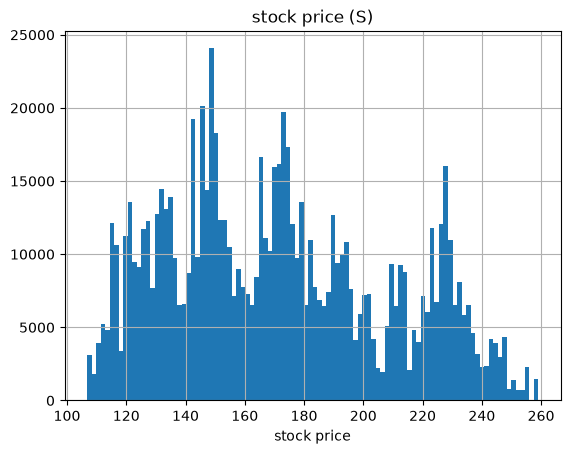

count    847997.000000
mean        171.204133
std          37.066659
min         106.840000
25%         142.450000
50%         168.450000
75%         197.960000
max         259.020000
Name: close, dtype: float64


In [52]:
aapl["close"].hist(bins=100)
plt.title("stock price (S)")
plt.xlabel("stock price")
plt.show()

print(aapl["close"].describe())

### 9. Moneyness (S/K)

Moneyness is constructed as `S/K`, following Hutchinson, Lo and Poggio (1994), reflecting the degree-one homogeneity of the option pricing function in `(S, K)` under the assumption that the underlying's return distribution is independent of its price level (Merton, 1990, Theorem 8.9).

In [53]:
aapl["moneyness (S/K)"] = aapl["close"] / aapl["strike_price"]

aapl["moneyness (S/K)"].describe()

count    847997.000000
mean          1.492963
std           2.314207
min           0.416733
25%           0.869822
50%           1.080556
75%           1.497437
max          51.804000
Name: moneyness (S/K), dtype: float64

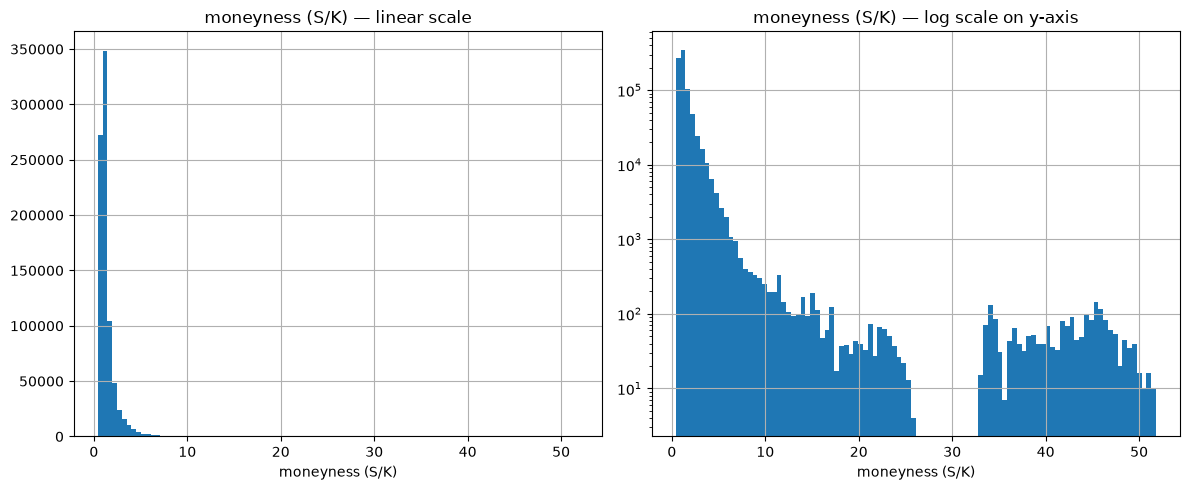

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

aapl["moneyness (S/K)"].hist(bins=100, ax=axes[0])
axes[0].set_title("moneyness (S/K) — linear scale")
axes[0].set_xlabel("moneyness (S/K)")

aapl["moneyness (S/K)"].hist(bins=100, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("moneyness (S/K) — log scale on y-axis")
axes[1].set_xlabel("moneyness (S/K)")

plt.tight_layout()
plt.show()

Investigate the gap in the distribution

In [55]:
# Fresh, self-contained load — tests whether the liquidity filter is responsible for the moneyness gap
df_raw = pd.read_csv("data/raw/AAPL_options_prices.csv")
df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw["strike_price"] = df_raw["strike_price"] / 1000

prices_raw = pd.read_csv("data/raw/AAPL_security_prices.csv")
prices_raw["date"] = pd.to_datetime(prices_raw["date"])

df_raw = df_raw.merge(prices_raw[["date", "close"]], on="date", how="left")
df_raw["moneyness_raw"] = df_raw["close"] / df_raw["strike_price"]

# Same strikes flagged as "extreme" in the cleaned dataset
strikes_of_interest = aapl[aapl["moneyness (S/K)"] > 20]["strike_price"].unique()

raw_subset = df_raw[df_raw["strike_price"].isin(strikes_of_interest)].sort_values("date")

print("Rows RAW (non filtrate) with moneyness in the gap range (26-33):")
print(((raw_subset["moneyness_raw"] > 26) & (raw_subset["moneyness_raw"] < 33)).sum())

Rows RAW (non filtrate) with moneyness in the gap range (26-33):
0


In [56]:
print(raw_subset.groupby("strike_price").agg(
    date_min=("date", "min"),
    date_max=("date", "max"),
    moneyness_min=("moneyness_raw", "min"),
    moneyness_max=("moneyness_raw", "max"),
))

               date_min   date_max  moneyness_min  moneyness_max
strike_price                                                    
5.0          2024-01-05 2025-08-29           33.0         51.804
10.0         2024-01-05 2025-08-29           16.5         25.902


### 10. Target variable 

The target variable is constructed as the option mid-price, `(best_bid + best_offer) / 2`, computed after the bid/ask validity checks in Section 5 to ensure both quotes are genuine.

In [57]:
aapl["price"] = (aapl["best_bid"] + aapl["best_offer"]) / 2

aapl["price"].describe()

count    847997.000000
mean         35.033130
std          42.696374
min           0.010000
25%           1.235000
50%          16.750000
75%          57.600000
max         254.550000
Name: price, dtype: float64

In [58]:
aapl.head()

,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price
0,101594,2020-08-31,2020-09-04,100.00,29.40,29.70,150,411,135212375,129.04,1.290400,29.550
1,101594,2020-08-31,2020-09-04,100.63,28.85,29.10,691,81,135212376,129.04,1.282321,28.975
2,101594,2020-08-31,2020-09-04,101.25,28.15,28.45,137,240,135212377,129.04,1.274469,28.300
3,101594,2020-08-31,2020-09-04,101.88,27.50,27.85,75,130,135212378,129.04,1.266588,27.675
4,101594,2020-08-31,2020-09-04,102.50,26.90,27.20,323,734,135212379,129.04,1.258927,27.050


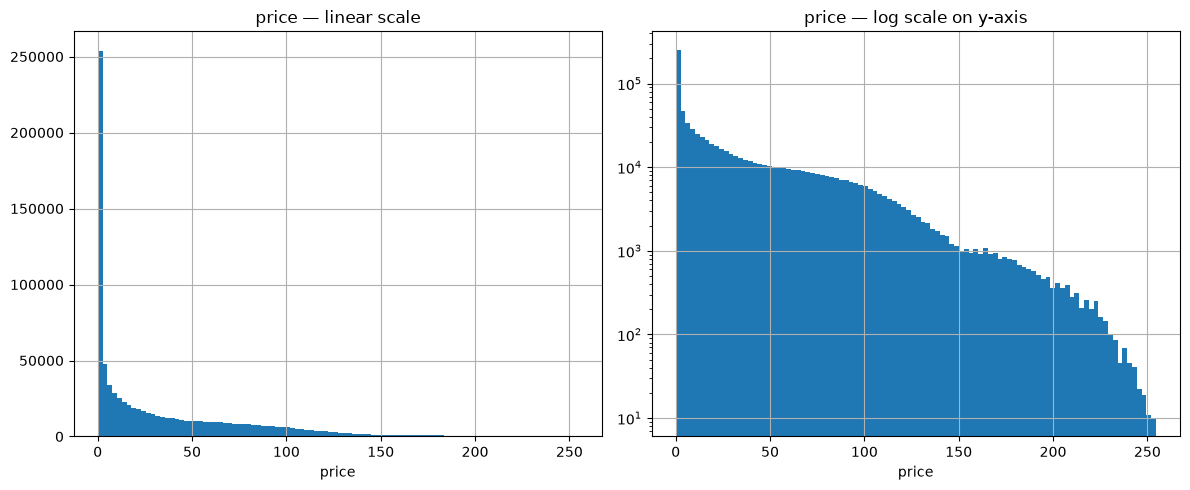

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

aapl["price"].hist(bins=100, ax=axes[0])
axes[0].set_title("price — linear scale")
axes[0].set_xlabel("price")

aapl["price"].hist(bins=100, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("price — log scale on y-axis")
axes[1].set_xlabel("price")

plt.tight_layout()
plt.show()

### 11. Merge historical volatility (60-day window)

Following Hutchinson, Lo and Poggio (1994), sigma is estimated as the realized volatility over a fixed 60-day trailing window, applied uniformly across all options regardless of their individual time to maturity. This choice may be revisited in favor of a per-option maturity-matched window later in the analysis.

In [60]:
historical_volatility = pd.read_csv(RAW_DATA_DIR / "AAPL_historical_volatility.csv")
historical_volatility["date"] = pd.to_datetime(historical_volatility["date"])

hv_60 = historical_volatility[historical_volatility["days"] == 60]

In [61]:
n_before = len(aapl)
aapl = aapl.merge(hv_60[["date", "volatility"]], on="date", how="left")
n_after = len(aapl)

print(f"Rows before merge: {n_before}")
print(f"Rows after merge: {n_after}")
print(f"Rows with missing underlying price after merge: {aapl['close'].isna().sum()}")
aapl.head()

Rows before merge: 847997
Rows after merge: 847997
Rows with missing underlying price after merge: 0


,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility
0,101594,2020-08-31,2020-09-04,100.00,29.40,29.70,150,411,135212375,129.04,1.290400,29.550,0.375779
1,101594,2020-08-31,2020-09-04,100.63,28.85,29.10,691,81,135212376,129.04,1.282321,28.975,0.375779
2,101594,2020-08-31,2020-09-04,101.25,28.15,28.45,137,240,135212377,129.04,1.274469,28.300,0.375779
3,101594,2020-08-31,2020-09-04,101.88,27.50,27.85,75,130,135212378,129.04,1.266588,27.675,0.375779
4,101594,2020-08-31,2020-09-04,102.50,26.90,27.20,323,734,135212379,129.04,1.258927,27.050,0.375779


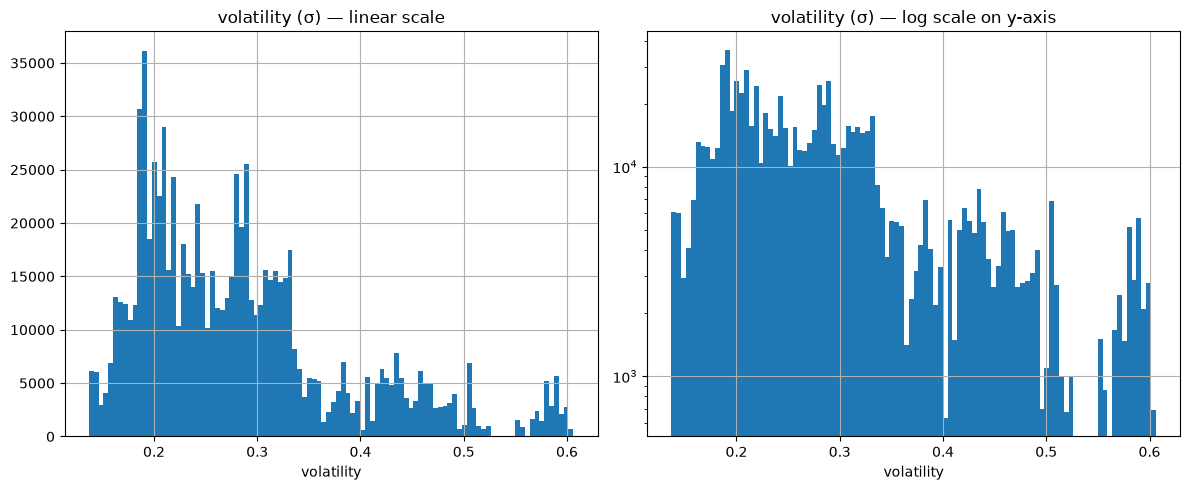

count    847997.000000
mean          0.284406
std           0.102060
min           0.137003
25%           0.205893
50%           0.264349
75%           0.327516
max           0.606078
Name: volatility, dtype: float64


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

aapl["volatility"].hist(bins=100, ax=axes[0])
axes[0].set_title("volatility (σ) — linear scale")
axes[0].set_xlabel("volatility")

aapl["volatility"].hist(bins=100, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("volatility (σ) — log scale on y-axis")
axes[1].set_xlabel("volatility")

plt.tight_layout()
plt.show()

print(aapl["volatility"].describe())

### 12. Merge risk-free rate (90-day tenor)

For each date, the zero-coupon rate closest to a 90-day maturity is selected from the Zero_Curve file, rather than requiring an exact match, since available tenors vary slightly around 90 days (89, 90, 91, ...) rather than following fixed standardized bins.

In [63]:
riskfree = pd.read_csv(RAW_DATA_DIR / "riskfree_rate.csv")
riskfree["date"] = pd.to_datetime(riskfree["date"])

In [64]:
riskfree["days_diff"] = (riskfree["days"] - 90).abs()
riskfree_90 = riskfree.loc[riskfree.groupby("date")["days_diff"].idxmin()][["date", "rate"]]

n_before = len(aapl)
aapl = aapl.merge(riskfree_90, on="date", how="left")
n_after = len(aapl)

print(f"Rows before merge: {n_before}")
print(f"Rows after merge: {n_after}")
print(f"Rows with missing rate after merge: {aapl['rate'].isna().sum()}")

Rows before merge: 847997
Rows after merge: 847997
Rows with missing rate after merge: 0


In [65]:
aapl["rate"] = aapl["rate"] / 100
print(aapl["rate"].describe())

count    847997.000000
mean          0.029992
std           0.021937
min           0.001026
25%           0.002142
50%           0.043964
75%           0.048890
max           0.055377
Name: rate, dtype: float64


In [66]:
aapl.head()

,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility,rate
0,101594,2020-08-31,2020-09-04,100.00,29.40,29.70,150,411,135212375,129.04,1.290400,29.550,0.375779,0.002148
1,101594,2020-08-31,2020-09-04,100.63,28.85,29.10,691,81,135212376,129.04,1.282321,28.975,0.375779,0.002148
2,101594,2020-08-31,2020-09-04,101.25,28.15,28.45,137,240,135212377,129.04,1.274469,28.300,0.375779,0.002148
3,101594,2020-08-31,2020-09-04,101.88,27.50,27.85,75,130,135212378,129.04,1.266588,27.675,0.375779,0.002148
4,101594,2020-08-31,2020-09-04,102.50,26.90,27.20,323,734,135212379,129.04,1.258927,27.050,0.375779,0.002148


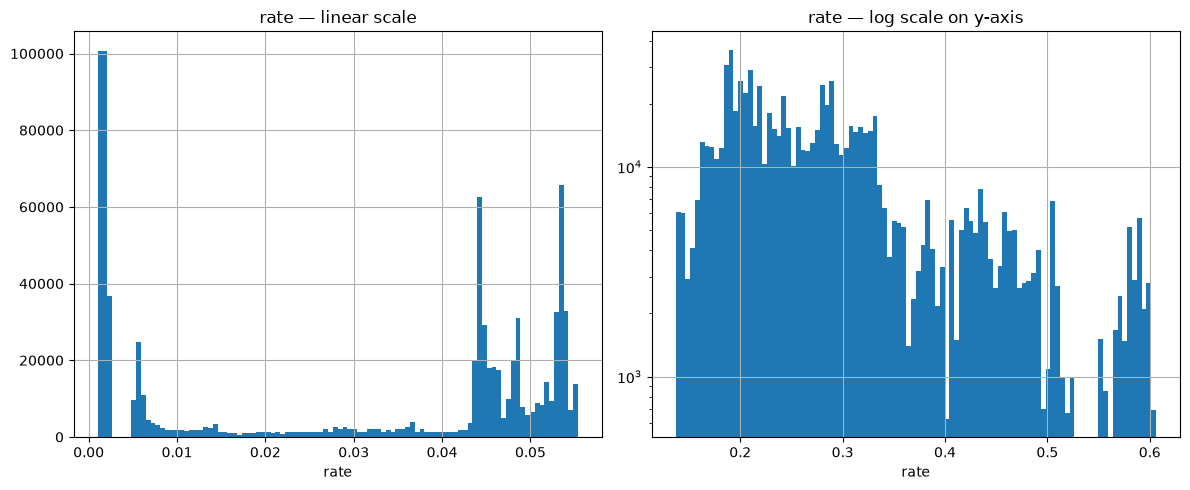

count    847997.000000
mean          0.029992
std           0.021937
min           0.001026
25%           0.002142
50%           0.043964
75%           0.048890
max           0.055377
Name: rate, dtype: float64


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

aapl["rate"].hist(bins=100, ax=axes[0])
axes[0].set_title("rate — linear scale")
axes[0].set_xlabel("rate")

aapl["volatility"].hist(bins=100, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("rate — log scale on y-axis")
axes[1].set_xlabel("rate")

plt.tight_layout()
plt.show()

print(aapl["rate"].describe())

### 13. Dividend yield (q)

#### Exclude same-day expirations (T = 0)

Options with zero days to expiration are excluded, since T = 0 causes a division by zero in the Black-Scholes d1/d2 terms. This exclusion is applied regardless of the broader minimum-maturity threshold decision (deferred to post-training analysis, following Hutchinson, Lo and Poggio, 1994), since it addresses a mathematical requirement of the pricing formula itself rather than a data-quality judgment.

In [68]:
aapl["days_to_maturity"] = (aapl["exdate"] - aapl["date"]).dt.days
aapl["T"] = aapl["days_to_maturity"] / 365

aapl["T"].describe()

count    847997.000000
mean          0.305302
std           0.279779
min           0.000000
25%           0.065753
50%           0.213699
75%           0.504110
max           1.000000
Name: T, dtype: float64

In [69]:
n_before = len(aapl)
aapl = aapl[aapl["T"] > 0].copy()
n_after = len(aapl)

print(f"Rows before: {n_before}")
print(f"Rows after excluding T = 0: {n_after}")
print(f"Rows removed: {n_before - n_after}")

Rows before: 847997
Rows after excluding T = 0: 838276
Rows removed: 9721


In [86]:
print(f"AAPL — median T: {aapl['T'].median()*365:.0f} days, "
      f"range: {aapl['T'].min()*365:.0f} - {aapl['T'].max()*365:.0f} days")

AAPL — median T: 79 days, range: 1 - 365 days


Following the OptionMetrics IvyDB methodology, `q` is computed as the most recently declared regular dividend divided by the underlying's closing price, held constant until the next declared dividend. Only actual declared dividends (`distr_type == 1`) are used, excluding cancelled distributions and yield projections (`distr_type == '%'`, where the `amount` field represents a yield rather than a dollar amount).

In [70]:
aapl_div = pd.read_csv(RAW_DATA_DIR / "AAPL_dividend_yield.csv")
aapl_div["ex_date"] = pd.to_datetime(aapl_div["ex_date"])

print(f"Rows: {len(aapl_div):,}")
print(f"Columns: {list(aapl_div.columns)}")

print(aapl_div.sort_values("ex_date").head(5))

Rows: 24
Columns: ['secid', 'record_date', 'ex_date', 'amount', 'adj_factor', 'distr_type', 'frequency', 'currency', 'approx_flag', 'cancel_flag', 'liquid_flag']
    secid record_date    ex_date  amount  adj_factor  distr_type  frequency  \
0  101594  2020-02-10 2020-02-07   0.770           1           1          3   
1  101594  2020-05-11 2020-05-08   0.820           1           1          3   
2  101594  2020-08-10 2020-08-07   0.820           1           1          3   
3  101594  2020-08-24 2020-08-31   0.000           4           2          3   
4  101594  2020-11-09 2020-11-06   0.205           1           1          3   

  currency  approx_flag  cancel_flag  liquid_flag  
0      USD            0            0            0  
1      USD            0            0            0  
2      USD            0            0            0  
3      NaN            0            0            0  
4      USD            0            0            0  


In [71]:
aapl_div = aapl_div[aapl_div["distr_type"] == 1].copy()
print(f"Rows after filtering to regular dividends only: {len(aapl_div)}")

Rows after filtering to regular dividends only: 23


In [72]:
split_date = pd.Timestamp("2020-08-31")
aapl_div.loc[aapl_div["ex_date"] < split_date, "amount"] /= 4

Creating the input variable q

In [73]:
# Prepare dividends sorted by ex_date, renamed for the as-of merge
aapl_div_sorted = (
    aapl_div[["ex_date", "amount", "frequency"]]
    .sort_values("ex_date") # already sorted but just to be sure
    .rename(columns={"ex_date": "date", "amount": "last_dividend"})
)

# For each option row, attach the most recent dividend paid on or before that date
aapl = aapl.sort_values("date")
aapl = pd.merge_asof(aapl, aapl_div_sorted, on="date", direction="backward")

aapl["q"] = aapl["last_dividend"] / aapl["close"]

print("Rows with missing q:", aapl["q"].isna().sum())
aapl["q"].describe()

Rows with missing q: 0


count    838276.000000
mean          0.001399
std           0.000215
min           0.000965
25%           0.001246
50%           0.001381
75%           0.001554
max           0.001919
Name: q, dtype: float64

In [74]:
aapl["q"] = (aapl["last_dividend"] / aapl["close"]) * aapl["frequency"]
aapl["q"].describe()

count    838276.000000
mean          0.004196
std           0.000644
min           0.002896
25%           0.003739
50%           0.004143
75%           0.004661
max           0.005756
Name: q, dtype: float64

In [75]:
aapl.head()

,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility,rate,days_to_maturity,T,last_dividend,frequency,q
0,101594,2020-08-31,2020-09-04,100.00,29.4,29.7,150,411,135212375,129.04,1.290400,29.55,0.375779,0.002148,4,0.010959,0.205,3,0.004766
1,101594,2020-08-31,2020-11-20,80.00,50.1,50.5,0,343,134244951,129.04,1.613000,50.30,0.375779,0.002148,81,0.221918,0.205,3,0.004766
2,101594,2020-08-31,2020-11-20,81.25,48.9,49.3,1,416,134244952,129.04,1.588185,49.10,0.375779,0.002148,81,0.221918,0.205,3,0.004766
3,101594,2020-08-31,2020-11-20,82.50,47.7,48.1,16,383,134244953,129.04,1.564121,47.90,0.375779,0.002148,81,0.221918,0.205,3,0.004766
4,101594,2020-08-31,2020-11-20,83.75,46.5,46.9,0,414,134244954,129.04,1.540776,46.70,0.375779,0.002148,81,0.221918,0.205,3,0.004766


## Summary

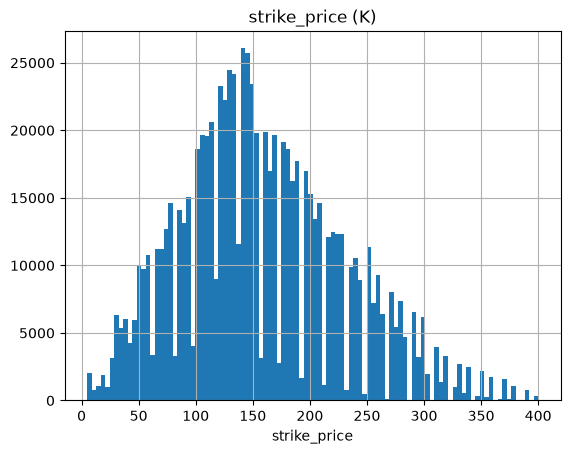

count    838276.000000
mean          0.004196
std           0.000644
min           0.002896
25%           0.003739
50%           0.004143
75%           0.004661
max           0.005756
Name: q, dtype: float64


In [76]:
aapl["strike_price"].hist(bins=100)
plt.title("strike_price (K)")
plt.xlabel("strike_price")
plt.show()


print(aapl["q"].describe())

Last check for negative values

In [77]:
# Positivity and validity checks on model inputs
n_before = len(aapl)
aapl = aapl[
    (aapl["strike_price"] > 0)
    & (aapl["close"] > 0)
    & (aapl["volatility"] > 0)
    & (aapl["price"] > 0)
    & (aapl["q"] >= 0)
].copy()
print(f"Rows removed by positivity checks: {n_before - len(aapl)}")

# Missing values in model inputs after all merges
model_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility", "price", "strike_price", "close"]
print(aapl[model_cols].isna().sum())

Rows removed by positivity checks: 0
moneyness (S/K)    0
T                  0
rate               0
q                  0
volatility         0
price              0
strike_price       0
close              0
dtype: int64


In [78]:
aapl.to_csv(RAW_DATA_DIR.parent / "processed" / "AAPL_cleaned.csv", index=False)
print(f"Saved {len(aapl)} rows to AAPL_cleaned.csv")

Saved 838276 rows to AAPL_cleaned.csv


## Summary

In [79]:
# Sample descriptives for the methodology chapter
security_prices = pd.read_csv("data/raw/AAPL_security_prices.csv", parse_dates=["date"])
security_prices = security_prices.sort_values("date")

first_close = security_prices["close"].iloc[0]
last_close = security_prices["close"].iloc[-1]

print(f"Sample period: {security_prices['date'].min().date()} to {security_prices['date'].max().date()}")
print(f"Trading days: {security_prices['date'].nunique()}")
print(f"Underlying: {first_close:.2f} -> {last_close:.2f} "
      f"({(last_close / first_close - 1) * 100:.1f}%)")
print(f"Underlying range: {security_prices['close'].min():.2f} - {security_prices['close'].max():.2f}")
print()
print(f"Observations after cleaning: {len(aapl):,}")
print(f"Distinct contracts: {aapl['optionid'].nunique():,}")
print(f"Trading days retained: {aapl['date'].nunique()}")
print(f"Option price range: {aapl['price'].min():.2f} - {aapl['price'].max():.2f}")
print(f"Moneyness range: {aapl['moneyness (S/K)'].min():.3f} - {aapl['moneyness (S/K)'].max():.3f}")
print(f"Maturity range (years): {aapl['T'].min():.4f} - {aapl['T'].max():.4f}")

Sample period: 2020-08-31 to 2025-08-29
Trading days: 1256
Underlying: 129.04 -> 232.14 (79.9%)
Underlying range: 106.84 - 259.02

Observations after cleaning: 838,276
Distinct contracts: 17,136
Trading days retained: 1256
Option price range: 0.01 - 254.55
Moneyness range: 0.417 - 51.804
Maturity range (years): 0.0027 - 1.0000
